In [68]:
%pip install pandas

In [69]:
# extracting files
import zipfile
import os
from pathlib import Path

table_path = Path('tabelas')
destination_dir = Path('extracted_tables')
destination_dir.mkdir(exist_ok=True)

for dir, subdirs, files in os.walk(table_path):
    for file in files:
      if(file.endswith('.zip')):
        zip_file_path = Path(dir) / file
        try:
          with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            extracted_table_path = destination_dir / zip_file_path.stem
            extracted_table_path.mkdir(exist_ok=True)
            zip_ref.extractall(path=extracted_table_path)
            print(f'Successfully extraction from: {zip_file_path}')
        except zipfile.BadZipFile:
          print(f'Error: {zip_file_path} is a bad or corrupted zip file.')
        except PermissionError:
          print(f'Error: Permission denied for {zip_file_path} or {extracted_table_path}.')
        except RuntimeError as e:
          print(f'Error extracting {zip_file_path}: {e}')
        except Exception as e:
          print(f'An unexpected error occurred with {zip_file_path}: {e}')

Successfully extraction from: tabelas/tabela6.zip
Successfully extraction from: tabelas/tabela2.zip
Successfully extraction from: tabelas/tabela3.zip
Successfully extraction from: tabelas/tabela5.zip
Successfully extraction from: tabelas/tabela1.zip
Successfully extraction from: tabelas/tabela4.zip


In [70]:
%pip install pyarrow
%pip install pyxlsb

In [71]:
#Reading tables to dataframes
import pandas as pd

df_1, df_2, df_3, df_4, df_5, df_6 = [None for i in range(6)]
for dirpath, subdirs, files in os.walk(destination_dir):
  for file in files:
    file_path = Path(dirpath) / file
    if file.endswith('.parquet'):
      df_1 = pd.read_parquet(file_path, engine='pyarrow')
    elif file.endswith('.csv'):
      try:
        df_2 = pd.read_csv(file_path, header=0, comment='#', sep=';', encoding='utf-16', dtype={'pot': str}, low_memory=False)
        df_2 = df_2.drop(columns=df_2.columns[0])
      except Exception:
        df_3 = pd.read_csv(file_path, header=None, sep='|')
    elif file.endswith('.jsonl'):
      df_4 = pd.read_json(file_path, lines=True)
    elif file.endswith('.txt'):
      df_5 = pd.read_csv(file_path, sep='\t')
    elif file.endswith('.xlsb'):
      df_6 = pd.read_excel(file_path, engine='pyxlsb', sheet_name='Dados')



In [72]:
# Handling the DF_2
df_2['CPF/CNPJ'] = df_2['CPF'].fillna(df_2['CNPJ'])
df_2 = df_2.drop(columns=['CPF', 'CNPJ'])
df_2 = df_2.rename(columns={'POTENCIA MÉDIA (kW)': 'POTENCIA_MEDIA', 'ESTADO': 'UF', 'DIA': 'DATA'})
print(df_2.head())

  CLASSE     POTENCIA_MEDIA        DATA            UF            CPF/CNPJ
0     D1  79.88906860351562  26-03-2024  Minas Gerais  46.193.767/5588-05
1     C2  42.57822799682617  06-06-2020         Goiás      210.480.466-68
2     A2  70.33451843261719  07-04-2020  Minas Gerais  43.449.875/2807-18
3     C1  74.99141693115234  09-04-2020     São Paulo  36.160.275/8062-05
4     A1  84.29060363769531  25-12-2022     São Paulo      398.688.422-84


In [73]:
#Handling the DF_3
df_3 = df_3.rename(columns={0: 'CPF/CNPJ', 1: 'UF', 2: 'POTENCIA_MEDIA', 3: 'DATA', 4: 'CLASSE'})
print(df_3.head())

             CPF/CNPJ         UF      POTENCIA_MEDIA        DATA CLASSE
0  64.541.500/2798-40      Goi�s            64,05213  21-12-2021     A2
1      715.992.871-51      Goi�s  141.69903564453125  07-02-2022     D1
2      820.118.049-27     Paran�   68.36085510253906  07-12-2022     D2
3  05.322.279/9078-77  S�o Paulo          107,848015  23-10-2021     A1
4  34.525.858/2228-34      Goi�s   101.6468276977539         NaN     A1


In [74]:
#Handling the DF_4
df_4 = df_4.rename(columns={'cpf_cnpj': 'CPF/CNPJ', 'estado': 'UF', 'pot': 'POTENCIA_MEDIA', 'data': 'DATA', 'tipo_classe': 'CLASSE'})
print(df_4.head())

             UF        DATA            CPF/CNPJ CLASSE      POTENCIA_MEDIA
0  Minas Gerais  28-06-2023      644.747.198-19     C1   52.01729202270508
1         Goiás  14-04-2022      450.910.099-15     D1           98,656425
2         Goiás  04-05-2024  69.166.474/8888-26     B1  125.23406219482422
3         Goiás  28-04-2024      175.648.670-18     C1   68.18346405029297
4        Paraná  19-06-2020      056.735.781-69     B1  40.372406005859375


In [75]:
#Handling the DF_6
df_6 = df_6.rename(columns={'CÓDIGO': 'CPF/CNPJ', 'UNIDADE FEDERATIVA': 'UF', 'MÉDIA DE POTÊNCIA (kW)': 'POTENCIA_MEDIA', 'DATA DO DIA': 'DATA'})
print(df_6.head())

             CPF/CNPJ            UF         POTENCIA_MEDIA        DATA CLASSE
0      265.932.892-91  Minas Gerais  21.795129776000977 kW  16-03-2021     D1
1  48.181.716/4779-20            SP    58.9128303527832 kW  16-01-2020     B1
2      480.598.177-99         Goiás    6.87807035446167 kW  06-12-2023     C2
3  09.923.526/5273-12     São Paulo   5.657987117767334 kW  30-01-2022     C2
4  50.251.475/9419-95     São Paulo   150.1721954345703 kW  22-05-2022     A2


In [76]:
# CLUSTERING OUR DATASETS
final_df = pd.concat([df_1, df_2, df_3, df_4, df_5, df_6], ignore_index=True)
print(final_df.head())
print(final_df.shape)

             CPF/CNPJ         UF      POTENCIA_MEDIA         DATA CLASSE
0      173.286.271-85      Goiás           125,23979   21-02-2022     D2
1  24.450.381/1961-78      Goiás  10.808021545410156  14/MAI/2023     A2
2  55.046.704/9244-16      Goiás   8.960883140563965   18-02-2023     C1
3  43.224.301/0000-73     Paraná   47.29384231567383   04-02-2023     D1
4  01.300.739/5028-43  São Paulo   79.22022247314453   03-12-2024     c2
(4419191, 5)


In [77]:
# Coluna CPF/CNPJ: Trate os valores para o mesmo padrão de CPF ou CNPJ. Caso o valor seja nulo ou esteja sem capacidade de ser transformado para um
# CPF ou CNPJ válido, descarte a linha.
import re

def clean_id(id):
  return re.sub(r'\D', '', str(id))

def find_type(id):
  return 'CPF' if len(id) == 11 else ('CNPJ' if len(id) == 14 else None)

def id_standardization(id):
  if find_type(id) == 'CPF':
    return f'{id[:3]}.{id[3:6]}.{id[6:9]}-{id[9:]}'
  else:
    return f'{id[0:2]}.{id[2:5]}.{id[5:8]}/{id[8:12]}-{id[12:]}'

final_df['CPF/CNPJ'] = final_df['CPF/CNPJ'].apply(clean_id)
final_df['id_type'] = final_df['CPF/CNPJ'].apply(find_type)
final_df = final_df[final_df['id_type'].notna()]
final_df = final_df.drop(columns=['id_type'])
final_df['CPF/CNPJ'] = final_df['CPF/CNPJ'].apply(id_standardization)
print(final_df.head(), final_df.shape, sep='\n')

             CPF/CNPJ         UF      POTENCIA_MEDIA         DATA CLASSE
0      173.286.271-85      Goiás           125,23979   21-02-2022     D2
1  24.450.381/1961-78      Goiás  10.808021545410156  14/MAI/2023     A2
2  55.046.704/9244-16      Goiás   8.960883140563965   18-02-2023     C1
3  43.224.301/0000-73     Paraná   47.29384231567383   04-02-2023     D1
4  01.300.739/5028-43  São Paulo   79.22022247314453   03-12-2024     c2
(4417446, 5)


In [78]:
%pip install numpy
import numpy as np

In [79]:
# Coluna UF: Trate os valores para o mesmo padrão de nome. Caso o valor seja nulo ou sem capacidade de compreender qual
# UF/Estado está se referindo, descarte a linha.
print(np.unique(final_df['UF']))
uf_options = {
  'GO': ['GO', 'GOIAS', 'Goiás', 'Goi�s'],
  'MG': ['MG', 'Minas Gerais'],
  'PR': ['PARANA', 'PR', 'Paraná', 'Paran�'],
  'SP': ['SAO PAULO', 'SP', 'São Paulo', 'S�o Paulo']
}

def uf_standardization(uf):
  if uf in uf_options['GO']:
    return 'GO'
  elif uf in uf_options['MG']:
    return 'MG'
  elif uf in uf_options['PR']:
    return 'PR'
  elif uf in uf_options['SP']:
    return 'SP'
  else:
    return None

final_df['UF'] = final_df['UF'].apply(uf_standardization)
final_df = final_df[final_df['UF'].notna()]
print(final_df.head())
print(final_df.shape)


[' ' 'GO' 'GOIAS' 'Goiás' 'Goi�s' 'MG' 'Minas Gerais' 'PARANA' 'PR'
 'Paraná' 'Paran�' 'SAO PAULO' 'SP' 'São Paulo' 'S�o Paulo']
             CPF/CNPJ  UF      POTENCIA_MEDIA         DATA CLASSE
0      173.286.271-85  GO           125,23979   21-02-2022     D2
1  24.450.381/1961-78  GO  10.808021545410156  14/MAI/2023     A2
2  55.046.704/9244-16  GO   8.960883140563965   18-02-2023     C1
3  43.224.301/0000-73  PR   47.29384231567383   04-02-2023     D1
4  01.300.739/5028-43  SP   79.22022247314453   03-12-2024     c2
(4406493, 5)


In [80]:
# Potência Média (kW): Trate os valores para float. Os dados estão em kW. Caso o valor seja nulo ou esteja sem
# capacidade de ser transformado em float, descarte a linha.
def pot_standardization(pot):
  try:
    pot_float = float(str(pot).replace(',', '.'))
    return pot_float
  except ValueError:
    return None

final_df['POTENCIA_MEDIA'] = final_df['POTENCIA_MEDIA'].apply(pot_standardization)
final_df = final_df[(final_df['POTENCIA_MEDIA'].notna()) & (final_df['POTENCIA_MEDIA'] >=0)]
print(final_df.head())
print(final_df.shape)

             CPF/CNPJ  UF  POTENCIA_MEDIA         DATA CLASSE
0      173.286.271-85  GO      125.239790   21-02-2022     D2
1  24.450.381/1961-78  GO       10.808022  14/MAI/2023     A2
2  55.046.704/9244-16  GO        8.960883   18-02-2023     C1
3  43.224.301/0000-73  PR       47.293842   04-02-2023     D1
4  01.300.739/5028-43  SP       79.220222   03-12-2024     c2
(3672093, 5)


In [81]:
# Data do Dia: Trate as datas para o mesmo formato de dia. Caso o valor seja nulo ou esteja sem capacidade de ser
# transformado em uma data válida, descarte a linha.

month_options = ['JAN', 'FEV', 'MAR', 'ABR', 'MAI', 'JUN', 'JUL', 'AGO', 'SET', 'OUT', 'NOV', 'DEZ']

def date_standardization(date: str):
  if '-' in date:
    return '/'.join(date.split('-', 3))
  elif date in ['None', 'nan']:
    return None
  else:
    pattern = r'(\d{2})/(\D{3})/(\d{4})'
    match = re.search(pattern, date)
    if match:
      month = match.group(2)
      month_number = month_options.index(month) + 1
      mm = str(month_number) if month_number >= 10 else '0' + str(month_number)
      dd, _, yyyy = date.split('/', 3)
      return f'{dd}/{mm}/{yyyy}'
    else:
      return date

final_df['DATA'] = final_df['DATA'].apply(str).apply(date_standardization)
final_df = final_df[final_df['DATA'].notna()]
print(final_df.head(), final_df.tail())
print(final_df.shape)


             CPF/CNPJ  UF  POTENCIA_MEDIA        DATA CLASSE
0      173.286.271-85  GO      125.239790  21/02/2022     D2
1  24.450.381/1961-78  GO       10.808022  14/05/2023     A2
2  55.046.704/9244-16  GO        8.960883  18/02/2023     C1
3  43.224.301/0000-73  PR       47.293842  04/02/2023     D1
4  01.300.739/5028-43  SP       79.220222  03/12/2024     c2                    CPF/CNPJ  UF  POTENCIA_MEDIA        DATA CLASSE
3682655  95.167.439/5584-35  GO      116.896280  01/02/2024     C2
3682656  25.916.235/0131-92  GO       99.347603  17/12/2024     B2
3682657      042.291.895-73  GO       47.104080  05/05/2021     B2
3682658      071.048.636-83  GO       37.696304  15/03/2021     A2
3682659  90.578.937/1169-59  MG       69.385086  16/11/2022     D1
(3571491, 5)


In [82]:
# Classe: Trate as classes para o mesmo formato. Caso o valor seja nulo ou esteja sem capacidade de ser transformado em uma das 8 classes, descarte a linha.
final_df['CLASSE'] = final_df['CLASSE'].str.upper()
print(np.unique(final_df['CLASSE']))

['A1' 'A2' 'B1' 'B2' 'C1' 'C2' 'D1' 'D2']


In [83]:
# Uma pessoa física/jurídica só pode ter um registro por dia, então remova os valores duplicados.
final_df = final_df.drop_duplicates(subset=['CPF/CNPJ'])

In [84]:
# Após essas tratativas, mostre, no notebook, como ficou o dataframe.
print(final_df)

                   CPF/CNPJ  UF  POTENCIA_MEDIA        DATA CLASSE
0            173.286.271-85  GO      125.239790  21/02/2022     D2
1        24.450.381/1961-78  GO       10.808022  14/05/2023     A2
2        55.046.704/9244-16  GO        8.960883  18/02/2023     C1
3        43.224.301/0000-73  PR       47.293842  04/02/2023     D1
4        01.300.739/5028-43  SP       79.220222  03/12/2024     C2
...                     ...  ..             ...         ...    ...
3370811  17.832.824/7121-14  PR       16.300684  05/02/2020     C1
3378245  62.965.484/0847-46  SP       10.630614  15/06/2021     D1
3426542      834.963.679-20  GO      127.920395  06/10/2024     D2
3509926  71.997.737/3673-72  MG       45.110640  26/05/2021     D1
3602396  99.593.328/8700-66  SP      145.471848  27/03/2020     A1

[40113 rows x 5 columns]


In [85]:
# Segunda Etapa - Transformação dos Dados
# Utilize o dataframe da primeira etapa para gerar uma nova coluna chamada CUSTO que é calculado utilizando a tabela de kWh/dia conforme a classe.
def calculate_cost(row):
  energy = row['POTENCIA_MEDIA'] * 24
  match row['CLASSE']:
    case 'A1':
      return 0.7 * energy
    case 'A2':
      return 0.7 * energy
    case 'B1':
      return 0.6 * energy
    case 'B2':
      return 0.3 * energy
    case 'C1':
      if row['POTENCIA_MEDIA'] > 50:
        return 1.5 * energy
      else:
        return 0.5 * energy
    case 'C2':
      if row['POTENCIA_MEDIA'] > 50:
        return 1.5 * energy
      else:
        return 0.5 * energy
    case 'D1':
      return 1.0 * energy
    case 'D2':
      return 1.0 * energy
    case default:
      raise Exception('Undefined class')

final_df['CUSTO'] = final_df.apply(calculate_cost, axis=1)
print(final_df.head())
print(final_df.shape)

             CPF/CNPJ  UF  POTENCIA_MEDIA        DATA CLASSE        CUSTO
0      173.286.271-85  GO      125.239790  21/02/2022     D2  3005.754960
1  24.450.381/1961-78  GO       10.808022  14/05/2023     A2   181.574762
2  55.046.704/9244-16  GO        8.960883  18/02/2023     C1   107.530598
3  43.224.301/0000-73  PR       47.293842  04/02/2023     D1  1135.052216
4  01.300.739/5028-43  SP       79.220222  03/12/2024     C2  2851.928009
(40113, 6)


In [86]:
%pip install matplotlib

In [87]:
import matplotlib.pyplot as plt

<Figure size 1200x600 with 0 Axes>

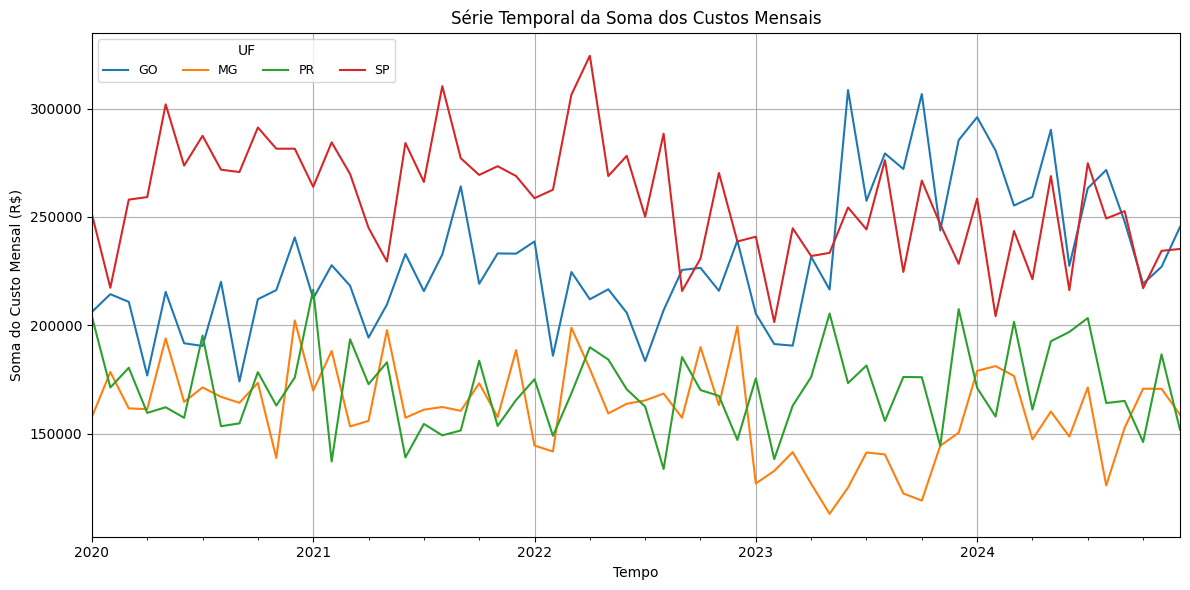

In [88]:
# Plote no notebook um Gráfico de Linhas Múltiplas (uma para cada UF) como Série Temporal da Soma dos Custos Mensais
final_df['DATA'] = pd.to_datetime(final_df['DATA'], format='%d/%m/%Y')
sample_df = final_df.copy(deep=True)

sample_df['YEAR_MONTH'] = sample_df['DATA'].dt.to_period('M')

# Aggregate
monthly_costs = sample_df.groupby(['YEAR_MONTH', 'UF'])['CUSTO'].sum().reset_index()

# Pivot to have one column per UF
pivot_df = monthly_costs.pivot(index='YEAR_MONTH', columns='UF', values='CUSTO')

# Sorting chronologically
pivot_df = pivot_df.sort_index()


plt.figure(figsize=(12, 6))
pivot_df.plot(kind='line', figsize=(12, 6))

plt.title('Série Temporal da Soma dos Custos Mensais')
plt.xlabel('Tempo')
plt.ylabel('Soma do Custo Mensal (R$)')
plt.grid(True)
plt.legend(title='UF', loc="upper left", ncol=4, fontsize=9)
plt.tight_layout()
plt.show()

In [89]:
%pip install XlsxWriter


In [90]:
# Planilha Excel
# Faça o código python que gere um arquivo excel contendo tabelas da somatória dos custo anual que cada CPF/CNPJ tem.
# Ou seja, uma coluna com valores únicos de CPF/CNPJ e outra com a soma anual dos custos que essa pessoa física/jurídica teve.
# Na planilha excel, separe em 5 abas, cada uma contendo apenas os registros de um ano. Ex: Aba 1 é de apenas 2020, Aba 2 é 2021, ...

sample_df = final_df.copy(deep=True)
sample_df['YEAR'] = sample_df['DATA'].dt.to_period("Y")


year_costs = sample_df.groupby(['YEAR', 'CPF/CNPJ'])['CUSTO'].sum().reset_index()
year_costs = year_costs.rename(columns={'CUSTO': 'CUSTO_ANUAL'})

with pd.ExcelWriter("customers_cost.xlsx", engine='xlsxwriter') as writer:
  for year, group in year_costs.groupby('YEAR'):
    group = group.drop(columns='YEAR')
    sheet_name = f'{year} Costs'
    group.to_excel(writer, sheet_name=sheet_name, index=False)
    workbook = writer.book
    worksheet = writer.sheets[sheet_name]

    header_format = workbook.add_format({
      "bold": True,
      "text_wrap": True,
      "valign": "middle",
      "align": "center",
      "bg_color": "#4472C4",
      "font_color": "white",
      "border": 1
    })

    money_format = workbook.add_format({"num_format": "R$ #,##0.00", "border": 1})
    text_format  = workbook.add_format({"border": 1})

    for col_num, value in enumerate(group.columns.values):
      worksheet.write(0, col_num, value, header_format)
      worksheet.set_column(col_num, col_num, 20)

    worksheet.set_column("A:A", 25, text_format)
    worksheet.set_column("B:B", 20, money_format)



In [101]:
# Perguntas
# Responda, no próprio notebook, as seguintes perguntas:

# 1. Qual UF/Estado possui a maior média de custo para a classe agrupada A (A1 e A2)?

class_a_df = final_df[(final_df['CLASSE'] == 'A1') | (final_df['CLASSE'] == 'A2')]
uf_cost_mean = class_a_df.groupby(['UF'])['CUSTO'].mean().reset_index()
selected_uf = uf_cost_mean[uf_cost_mean['CUSTO'] == uf_cost_mean['CUSTO'].max()]['UF'].values[0]
print(selected_uf)

# 2. Qual UF/Estado possui a maior média de custo para a classe agrupada B (B1 e B2)?

class_b_df = final_df[(final_df['CLASSE'] == 'B1') | (final_df['CLASSE'] == 'B2')]
uf_cost_mean = class_b_df.groupby(['UF'])['CUSTO'].mean().reset_index()
selected_uf = uf_cost_mean[uf_cost_mean['CUSTO'] == uf_cost_mean['CUSTO'].max()]['UF'].values[0]
print(selected_uf)

# 3. Qual UF/Estado possui a maior média de custo para a classe agrupada C (C1 e C2)?

class_c_df = final_df[(final_df['CLASSE'] == 'C1') | (final_df['CLASSE'] == 'C2')]
uf_cost_mean = class_c_df.groupby(['UF'])['CUSTO'].mean().reset_index()
selected_uf = uf_cost_mean[uf_cost_mean['CUSTO'] == uf_cost_mean['CUSTO'].max()]['UF'].values[0]
print(selected_uf)

# 4. Qual UF/Estado possui a maior média de custo para a classe agrupada D (D1 e D2)?

class_d_df = final_df[(final_df['CLASSE'] == 'D1') | (final_df['CLASSE'] == 'D2')]
uf_cost_mean = class_d_df.groupby(['UF'])['CUSTO'].mean().reset_index()
selected_uf = uf_cost_mean[uf_cost_mean['CUSTO'] == uf_cost_mean['CUSTO'].max()]['UF'].values[0]
print(selected_uf)



SP
PR
SP
GO
